In [ ]:
# linear regression = >predict [0 -1]


# 2 option
#  -  OLM (ordinary least square method) y = beta_0 + beta_1x ..SSE  Square Sum of error
# #  find best beta_0 and beta_1 value to miminize the SSE error
#   - MLE (maximum likelihood)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib as mpl
from matplotlib import pyplot as plt

In [ ]:
data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv", index_col=0)

In [ ]:
data_df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


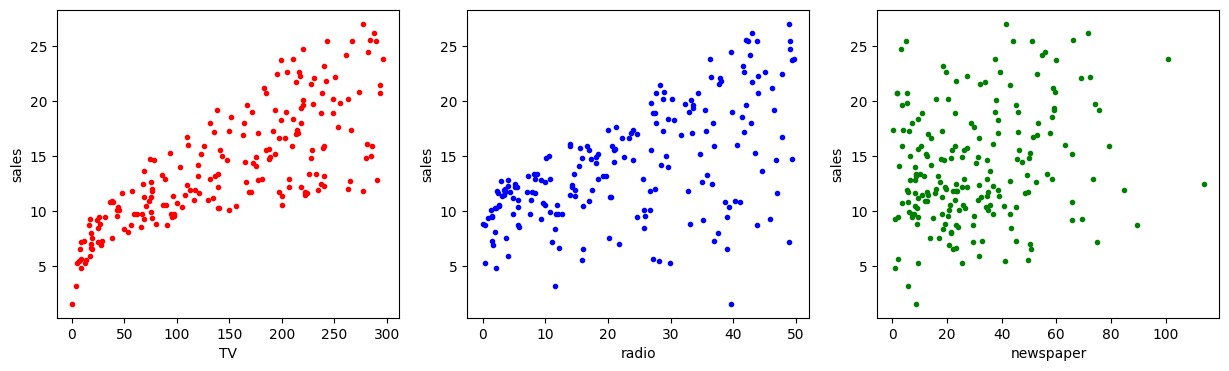

In [ ]:
fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3) #row * column

#plot of sales vs TV
ax = fig.add_subplot(gs[0])
ax.scatter(data_df["TV"], data_df["sales"], color="red", marker=".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")

#plot of sales vs radio
ax = fig.add_subplot(gs[1])
ax.scatter(data_df["radio"], data_df["sales"], color="blue", marker=".")
ax.set_xlabel("radio")
ax.set_ylabel("sales")

#plot of sales vs newspaper
ax = fig.add_subplot(gs[2])
ax.scatter(data_df["newspaper"], data_df["sales"], color="green", marker=".")
ax.set_xlabel("newspaper")
ax.set_ylabel("sales")

plt.show()

In [ ]:
X = data_df.TV.to_numpy()
Y = data_df.sales.to_numpy()

In [ ]:
# beta_1
x_mean = X.mean()
y_mean = Y.mean()

In [ ]:
beta_1 = np.sum((X - x_mean) * (Y - y_mean)) /np.sum(np.power((X - x_mean), 2))
beta_0 = y_mean - (beta_1 * x_mean)

In [ ]:
print(f"y = {beta_0:.2f} +{beta_1:.2f}x")

y = 7.03 +0.05x


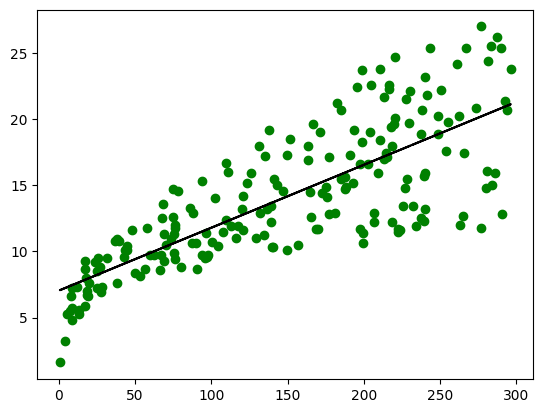

In [ ]:
plt.scatter(X,Y, color="green")
plt.plot(X, beta_0 + (beta_1 * X), color = "black")

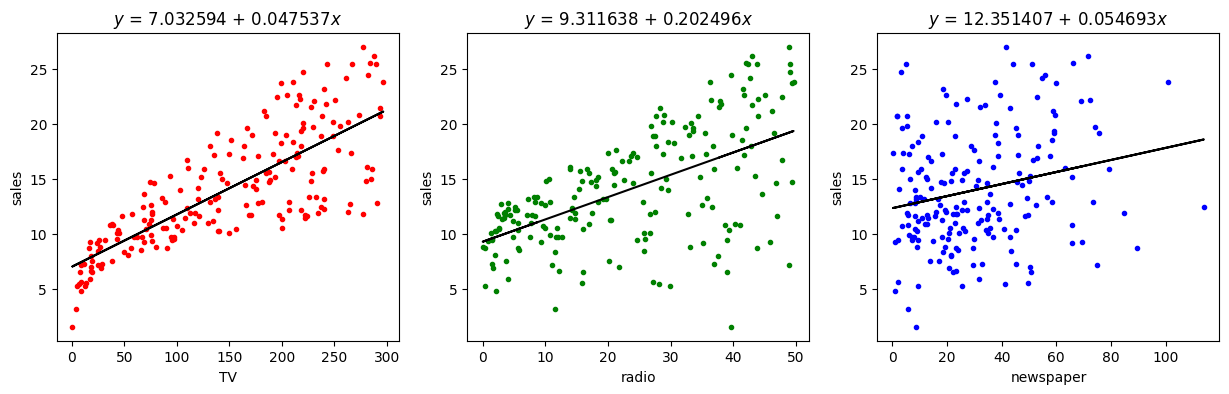

In [ ]:
fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

def train_plot(data_df, feature, ax, c):
  X = data_df[feature].to_numpy()
  Y = data_df['sales'].to_numpy()

  x_mean = X.mean()
  y_mean = Y.mean()

  beta_1 = np.sum((X - x_mean) * (Y - y_mean)) /np.sum(np.power((X - x_mean), 2))
  beta_0 = y_mean - (beta_1 * x_mean)

  y_hat = beta_0 + np.dot(X, beta_1)

  # plotthe regression lines
  ax.scatter(data_df[feature], data_df["sales"], color = c, marker=".")
  ax.plot(X, y_hat, color="black")
  ax.set_xlabel(feature)
  ax.set_ylabel("sales")
  ax.set_title(("$y$ = %2f + %2f$x$" %(beta_0, beta_1)))

ax0 = fig.add_subplot(gs[0])
train_plot(data_df, "TV", ax0, "red")

ax1 = fig.add_subplot(gs[1])
train_plot(data_df, "radio", ax1, "green")

ax2 = fig.add_subplot(gs[2])
train_plot(data_df, "newspaper", ax2, "blue")


In [ ]:
# Implemetataion using SKlearn

from sklearn.linear_model import LinearRegression


In [ ]:
linear_reg = LinearRegression()

In [ ]:
X.shape

(200,)

In [ ]:
Y.shape

(200,)

In [ ]:
X

array([230.1,  44.5,  17.2, 151.5, 180.8,   8.7,  57.5, 120.2,   8.6,
       199.8,  66.1, 214.7,  23.8,  97.5, 204.1, 195.4,  67.8, 281.4,
        69.2, 147.3, 218.4, 237.4,  13.2, 228.3,  62.3, 262.9, 142.9,
       240.1, 248.8,  70.6, 292.9, 112.9,  97.2, 265.6,  95.7, 290.7,
       266.9,  74.7,  43.1, 228. , 202.5, 177. , 293.6, 206.9,  25.1,
       175.1,  89.7, 239.9, 227.2,  66.9, 199.8, 100.4, 216.4, 182.6,
       262.7, 198.9,   7.3, 136.2, 210.8, 210.7,  53.5, 261.3, 239.3,
       102.7, 131.1,  69. ,  31.5, 139.3, 237.4, 216.8, 199.1, 109.8,
        26.8, 129.4, 213.4,  16.9,  27.5, 120.5,   5.4, 116. ,  76.4,
       239.8,  75.3,  68.4, 213.5, 193.2,  76.3, 110.7,  88.3, 109.8,
       134.3,  28.6, 217.7, 250.9, 107.4, 163.3, 197.6, 184.9, 289.7,
       135.2, 222.4, 296.4, 280.2, 187.9, 238.2, 137.9,  25. ,  90.4,
        13.1, 255.4, 225.8, 241.7, 175.7, 209.6,  78.2,  75.1, 139.2,
        76.4, 125.7,  19.4, 141.3,  18.8, 224. , 123.1, 229.5,  87.2,
         7.8,  80.2,

In [ ]:
X.reshape(-1,1).shape #reshape(rows, column)

(200, 1)

In [ ]:
linear_reg.fit(X.reshape(-1,1), Y.reshape(-1,1))


LinearRegression()

In [ ]:
linear_reg.coef_

array([[0.04753664]])

In [ ]:
linear_reg.intercept_

array([7.03259355])